In [65]:
#sarinakasaiyan

In [66]:
from transformers import T5Tokenizer, T5ForConditionalGeneration, MarianTokenizer, MarianMTModel
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize
import nltk
import time

In [67]:
# دانلود منابع مورد نیاز NLTK
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [68]:
# بارگذاری مدل T5
t5_tokenizer = T5Tokenizer.from_pretrained('t5-small')
t5_model = T5ForConditionalGeneration.from_pretrained('t5-small')


In [69]:
# بارگذاری مدل‌های Marian برای انگلیسی به فرانسوی و انگلیسی به آلمانی
marian_tokenizer_en_fr = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-fr')
marian_model_en_fr = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-en-fr')
marian_tokenizer_en_de = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-de')
marian_model_en_de = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-en-de')

In [70]:
# تعریف متن ورودی انگلیسی
input_text = "Where Ideas Meet Innovation: Let's Build Robots"

In [71]:
# نمایش توکن‌ها
print("\nTokens:")
print("T5 tokens:", t5_tokenizer.convert_ids_to_tokens(t5_input_ids_fr[0]))
print("Marian tokens:", marian_tokenizer_en_fr.convert_ids_to_tokens(marian_input_ids[0]))



Tokens:
T5 tokens: ['▁translate', '▁English', '▁to', '▁French', ':', '▁Where', '▁Ideas', '▁Meet', '▁Innovation', ':', '▁Let', "'", 's', '▁Build', '▁Robot', 's', '</s>']
Marian tokens: ['▁Where', '▁I', 'de', 'as', '▁Meet', '▁Innovation', ':', '▁Let', "'", 's', '▁Build', '▁Robot', 's', '</s>']


In [72]:
# ترجمه با T5
t5_input_fr = "translate English to French: " + input_text
t5_input_de = "translate English to German: " + input_text

t5_input_ids_fr = t5_tokenizer.encode(t5_input_fr, return_tensors='pt')
t5_input_ids_de = t5_tokenizer.encode(t5_input_de, return_tensors='pt')

start_time = time.time()
t5_outputs_fr = t5_model.generate(t5_input_ids_fr)
t5_output_text_fr = t5_tokenizer.decode(t5_outputs_fr[0], skip_special_tokens=True)
t5_outputs_de = t5_model.generate(t5_input_ids_de)
t5_output_text_de = t5_tokenizer.decode(t5_outputs_de[0], skip_special_tokens=True)
t5_model_time = time.time() - start_time


In [73]:
# ترجمه با Marian
marian_input_ids = marian_tokenizer_en_fr(input_text, return_tensors='pt').input_ids


In [74]:
# متن‌های مرجع (ترجمه‌های تقریبی)
reference_text_fr = "Là où les idées rencontrent l'innovation : Construisons des robots"
reference_text_de = "Wo Ideen auf Innovation treffen: Lasst uns Roboter bauen"


In [75]:

# توکن‌بندی متن‌های مرجع و خروجی
reference_tokens_fr = word_tokenize(reference_text_fr)
reference_tokens_de = word_tokenize(reference_text_de)
t5_output_tokens_fr = word_tokenize(t5_output_text_fr)
t5_output_tokens_de = word_tokenize(t5_output_text_de)
marian_output_tokens_fr = word_tokenize(marian_output_text_fr)
marian_output_tokens_de = word_tokenize(marian_output_text_de)

In [76]:
# محاسبه امتیاز METEOR
t5_meteor_score_fr = meteor_score([reference_tokens_fr], t5_output_tokens_fr)
t5_meteor_score_de = meteor_score([reference_tokens_de], t5_output_tokens_de)
marian_meteor_score_fr = meteor_score([reference_tokens_fr], marian_output_tokens_fr)
marian_meteor_score_de = meteor_score([reference_tokens_de], marian_output_tokens_de)

In [77]:
marian_model_en_de = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-en-de')


In [78]:
# چاپ نتایج
print("Input: ", input_text)
print("T5 French output: ", t5_output_text_fr)
print("T5 German output: ", t5_output_text_de)
print("Marian French output: ", marian_output_text_fr)
print("Marian German output: ", marian_output_text_de)
print("T5 French METEOR score: {:.2f}".format(t5_meteor_score_fr))
print("T5 German METEOR score: {:.2f}".format(t5_meteor_score_de))
print("Marian French METEOR score: {:.2f}".format(marian_meteor_score_fr))
print("Marian German METEOR score: {:.2f}".format(marian_meteor_score_de))
print("T5 model time: {:.2f} seconds".format(t5_model_time))
print("Marian model time: {:.2f} seconds".format(marian_model_time))


Input:  Where Ideas Meet Innovation: Let's Build Robots
T5 French output:  Où les idées rencontrent l'innovation : bâtissons des robots
T5 German output:  Wo Innovationen treffen: Lassen Sie uns Roboter bauen
Marian French output:  Où les idées rencontrent l'innovation : construisons des robots
Marian German output:  "Gemeinschaftskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodierungskodieru

In [79]:
# مقایسه مستقیم
print("\nComparison:")
print(f"T5 French: {t5_output_text_fr}")
print(f"Marian French: {marian_output_text_fr}")
print(f"T5 METEOR Score: {t5_meteor_score_fr:.2f}")
print(f"Marian METEOR Score: {marian_meteor_score_fr:.2f}")
print(f"T5 Model Time: {t5_model_time:.2f} seconds")
print(f"Marian Model Time: {marian_model_time:.2f} seconds")



Comparison:
T5 French: Où les idées rencontrent l'innovation : bâtissons des robots
Marian French: Où les idées rencontrent l'innovation : construisons des robots
T5 METEOR Score: 0.80
Marian METEOR Score: 0.91
T5 Model Time: 0.96 seconds
Marian Model Time: 36.83 seconds


In [80]:
from tabulate import tabulate

results = [
    ["Model", "French Output", "METEOR Score", "Time (s)"],
    ["T5", t5_output_text_fr, f"{t5_meteor_score_fr:.2f}", f"{t5_model_time:.2f}"],
    ["Marian", marian_output_text_fr, f"{marian_meteor_score_fr:.2f}", f"{marian_model_time:.2f}"]
]

print("\nComparison Table:")
print(tabulate(results, headers="firstrow", tablefmt="grid"))



Comparison Table:
+---------+-----------------------------------------------------------------+----------------+------------+
| Model   | French Output                                                   |   METEOR Score |   Time (s) |
+=========+=================================================================+================+============+
| T5      | Où les idées rencontrent l'innovation : bâtissons des robots    |           0.8  |       0.96 |
+---------+-----------------------------------------------------------------+----------------+------------+
| Marian  | Où les idées rencontrent l'innovation : construisons des robots |           0.91 |      36.83 |
+---------+-----------------------------------------------------------------+----------------+------------+


In [81]:
!pip install seaborn


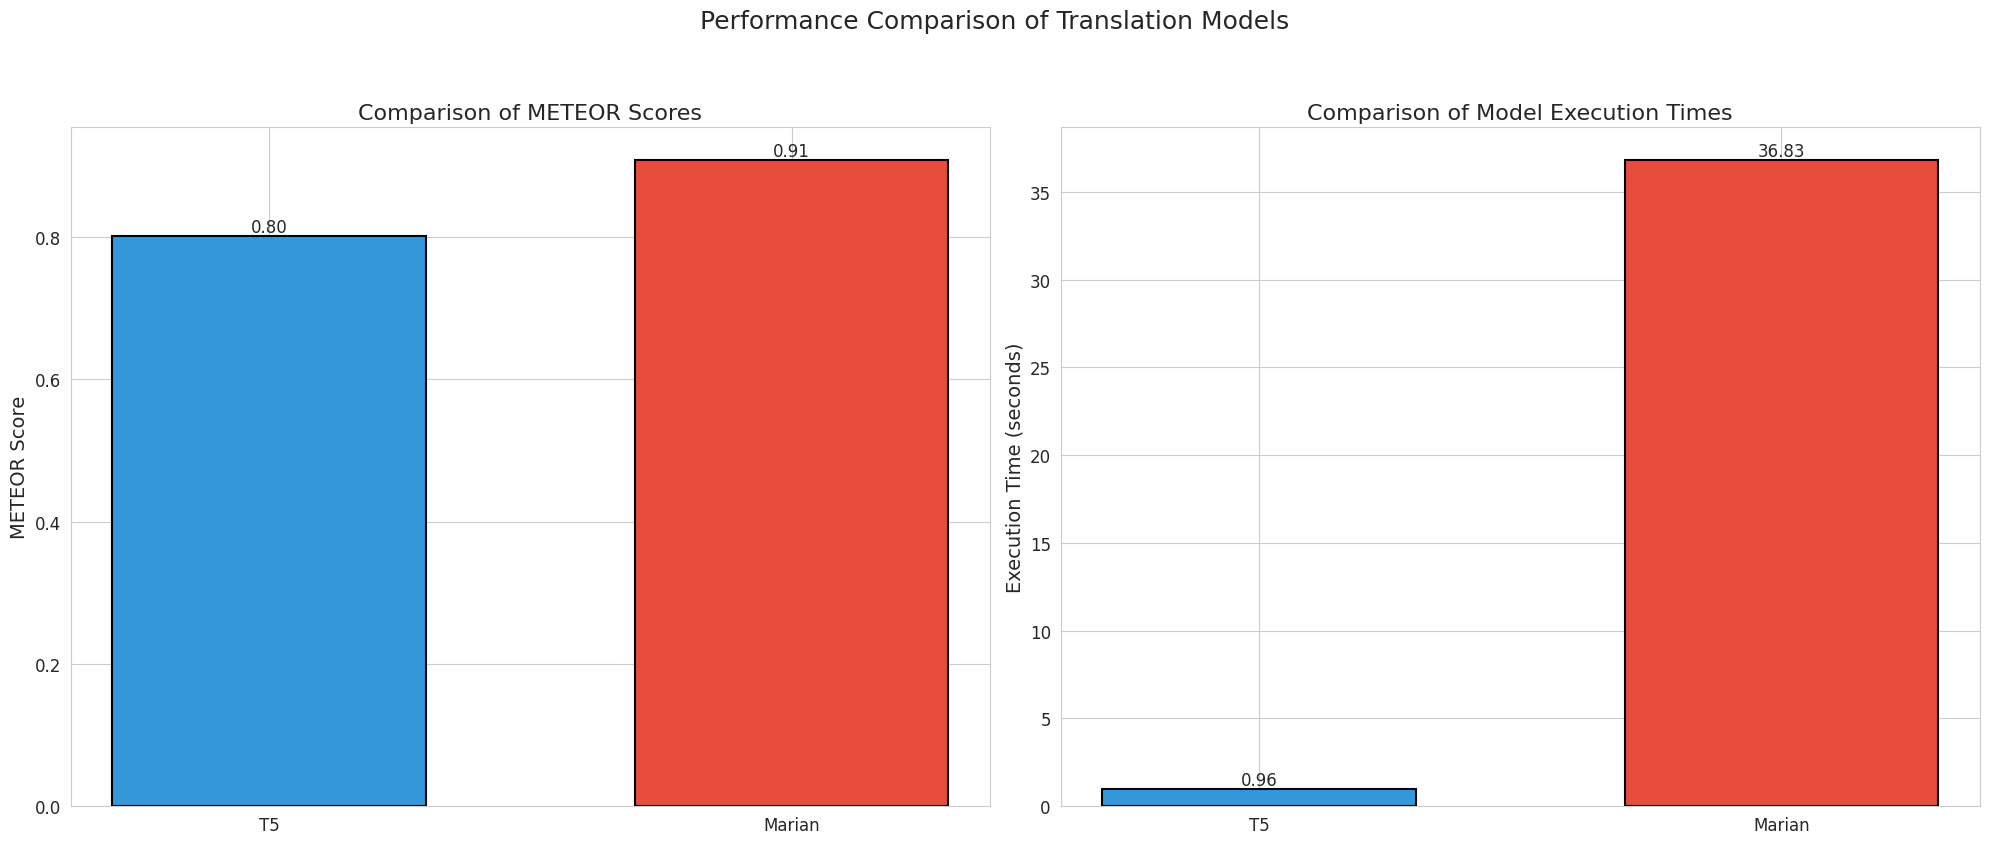

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data
models = ['T5', 'Marian']
meteor_scores = [t5_meteor_score_fr, marian_meteor_score_fr]
execution_times = [t5_model_time, marian_model_time]

# Color and style settings
sns.set_style("whitegrid")
colors = ['#3498db', '#e74c3c']  # Blue and Red

# Create plot with more space between subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
plt.subplots_adjust(wspace=0.3)

# METEOR scores chart
bars1 = ax1.bar(models, meteor_scores, color=colors, edgecolor='black', linewidth=1.5, width=0.6)
ax1.set_ylabel('METEOR Score', fontsize=14)
ax1.set_title('Comparison of METEOR Scores', fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=12)

# Add values on top of bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=12)

# Execution time chart
bars2 = ax2.bar(models, execution_times, color=colors, edgecolor='black', linewidth=1.5, width=0.6)
ax2.set_ylabel('Execution Time (seconds)', fontsize=14)
ax2.set_title('Comparison of Model Execution Times', fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=12)

# Add values on top of bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=12)

# Overall settings
plt.suptitle('Performance Comparison of Translation Models', fontsize=18, y=1.05)
plt.tight_layout()

# Display the chart
plt.show()
